# Ecological Trajectories: Cluster Exploration

This notebook visualizes assigned clusters from spatial results and allows exploring the raw GPP and SVH time series for specific pixels. 

**Key Features:**
- Uses **DuckDB** to query the 3.4GB Parquet file efficiently without loading it into memory.
- Matches records by **coordinates** for precision.
- Provides cluster-stratified random sampling for exploration.

In [2]:
import duckdb
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import leafmap.maplibregl as leafmap
import os
import numpy as np

# Ensure UTF-8 encoding on Windows
os.environ['PYTHONUTF8'] = '1'

# Data paths
DIR = os.path.dirname(os.getcwd())
cluster_file = os.path.join(DIR, 'data', 'trajectory_results_spatial_subset.geojson')
raw_file = os.path.join(DIR, 'data', 'abandoned_ag_gpp_2000_2022_SA.parquet')

## 1. Load Cluster Data

Load the spatial results containing cluster assignments.

In [3]:
print(f"Loading {cluster_file}...")
gdf = gpd.read_file(cluster_file)
print(f"Loaded {len(gdf)} points.")
gdf.head()

Loading c:\Users\coach\myfiles\postdoc2\code\data\trajectory_results_spatial_subset.geojson...
Loaded 216976 points.


,cluster,cluster_prob,geometry
0,1,1.0,POINT (18.83888 -32.7448)
1,1,1.0,POINT (18.83107 -32.74346)
2,1,1.0,POINT (18.83376 -32.74211)
3,1,1.0,POINT (18.83942 -32.73672)
4,1,1.0,POINT (18.86503 -32.76017)


## 2. Visualize Clusters on Interactive Map

In [12]:
import leafmap.maplibregl as leafmap

# Specify years for Wayback imagery

m = leafmap.Map(center=[point.geometry.x, point.geometry.y], zoom=15, sidebar_visible=True)
m.add_wayback_layer(date="1990-02-20")
m.add_wayback_layer(date="2025-09-25")

# Add base satellite layer
# m.add_basemap("SATELLITE")

m.add_wms_layer(
    url="http://apollo.cdngiportal.co.za/erdas-iws/ogc/wms/CDNGI_PORTAL_BACKDROP",
    layers="CDNGI_Imagery_25cm_MOSAICS",
    name="CDNGI High-Res Imagery",
    visible=False
)
# Add marker at the pixel location
m.add_marker(
    lng_lat=[point.geometry.x, point.geometry.y],  # Note: marker uses [lon, lat]
    options={
        "color": "red",
    }
)
m


1990-02-20 is not available. Using the closest date: 2014-02-20


Html(children=[<leafmap.maplibregl.Map object at 0x000001F56430C510>, Card(children=[Row(children=[Btn(childre…

## 3. Profile Raw Time Series

Select a pixel by cluster and visualize its raw GPP/SVH data. We use coordinates to match the spatial results with the large raw time series file.

--------------------------------------------------
Coordinates: -32.849099, 19.331790
Assigned Cluster: 1
Cluster Probability: 1.0000
--------------------------------------------------


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

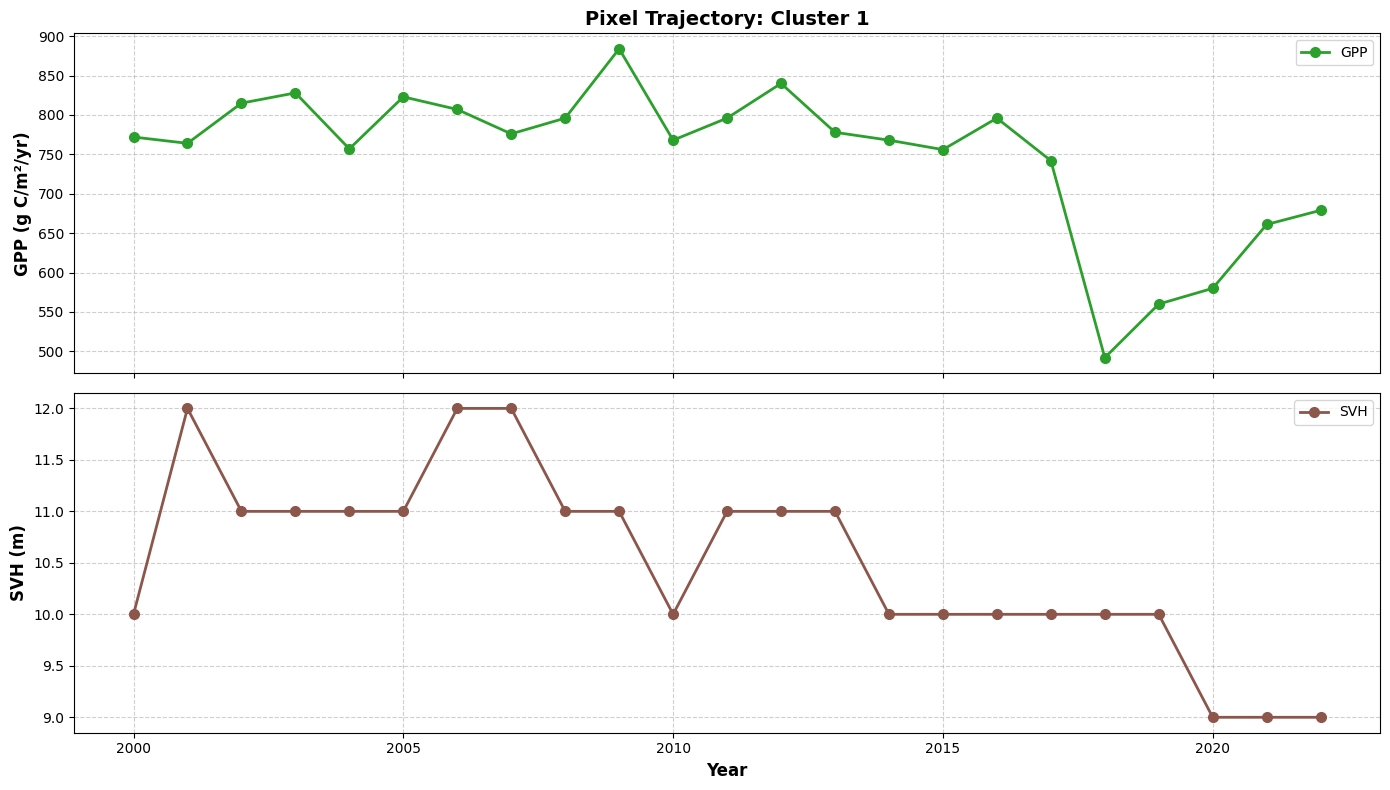

In [4]:
# SETTINGS: Pick a cluster to explore
TARGET_CLUSTER = 1
PRECISION = 0.000001 # Coordinate matching tolerance

cluster_subset = gdf[gdf['cluster'] == TARGET_CLUSTER]
if not cluster_subset.empty:
    point = cluster_subset.sample(1).iloc[0]
else:
    point = gdf.iloc[0]
    print("Target cluster not found, using first point.")

lon, lat = point.geometry.x, point.geometry.y

print(f"--------------------------------------------------")
print(f"Coordinates: {lat:.6f}, {lon:.6f}")
print(f"Assigned Cluster: {int(point['cluster'])}")
print(f"Cluster Probability: {point['cluster_prob']:.4f}")
print(f"--------------------------------------------------")

# Connect to DuckDB and query only the required row
con = duckdb.connect()
query = f"""
SELECT * 
FROM read_parquet('{raw_file}')
WHERE ABS(latitude - {lat}) < {PRECISION}
  AND ABS(longitude - {lon}) < {PRECISION}
LIMIT 1
"""
raw_data = con.execute(query).df()
con.close()

if raw_data.empty:
    print("ERROR: Could not find matching coordinates in raw data file.")
else:
    # Extract GPP and SVH columns
    gpp_cols = [c for c in raw_data.columns if c.startswith('GPP_')]
    svh_cols = [c for c in raw_data.columns if c.startswith('SVH_')]
    years = [int(c.split('_')[1]) for c in gpp_cols]
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
    # GPP Plot
    ax1.plot(years, raw_data[gpp_cols].iloc[0].values, 'o-', 
             color='#2ca02c', linewidth=2, markersize=7, label='GPP')
    ax1.set_ylabel("GPP (g C/m²/yr)", fontsize=12, fontweight='bold')
    ax1.set_title(f"Pixel Trajectory: Cluster {int(point['cluster'])}", fontsize=14, fontweight='bold')
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend()

    # SVH Plot
    ax2.plot(years, raw_data[svh_cols].iloc[0].values, 'o-', 
             color='#8c564b', linewidth=2, markersize=7, label='SVH')
    ax2.set_ylabel("SVH (m)", fontsize=12, fontweight='bold')
    ax2.set_xlabel("Year", fontsize=12, fontweight='bold')
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()